# Mass-univariate screen of individual environmental items

This notebook screens individual baseline environmental items against the **NODDI + macrostructure** white-matter feature set using **split-half A only** for now. Each item is tested separately with the same nuisance covariates as the primary analysis: age, sex, and image quality. No DKI and no brain-size adjustment are included.

Key outputs:
- item missingness / simple numeric-type summary
- partial-r, t, p, and per-item BH-FDR results across 1,302 WM features
- one FDR-masked tract × metric heatmap per item
- comparison of each item effect map with the General Exposome (`General_SES`)
- ranking by mean absolute partial r
- ranking by number of FDR-significant WM features
- optional tract-level and metric-level summary heatmaps for the top-ranked items

The analysis file and group filter are defined once below so this can later be switched to a full-sample harmonized dataset easily.

In [1]:
from pathlib import Path
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_rows",100)
pd.set_option("display.max_columns",100)

ROOT_DIR=Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
INPUT_DIR=ROOT_DIR/"input_data"
RESULTS_DIR=ROOT_DIR/"output_data"/"results"
OUT_DIR=RESULTS_DIR/"reviewer_revision"/"individual_environment_items"
HEATMAP_DIR=OUT_DIR/"item_heatmaps"
OUT_DIR.mkdir(parents=True,exist_ok=True)
HEATMAP_DIR.mkdir(parents=True,exist_ok=True)

# Easy to change later if a full-sample harmonized file becomes available.
IMAGING_FILE=RESULTS_DIR/"dfA_macro_plus_NODDI_12_10.csv"
MATCHED_GROUP_FILTER=1   # split-half A; set to None for a future full-sample file
ITEM_FILE=INPUT_DIR/"ABCD_to_send.csv"
BASELINE_EVENT="baseline_year_1_arm_1"

NUISANCE_COLS=["age","sex","t1post_dwi_contrast"]
GENERAL_EXPOSOME="General_SES"
MISSING_CODE=99999       # special missing code only in ABCD_to_send.csv environmental variables
MIN_N=100
SAVE_ITEM_HEATMAPS=False # keep off while validating numeric results
SUMMARY_TOP_N=30

print("Imaging file:",IMAGING_FILE)
print("Item file:",ITEM_FILE)
print("Output:",OUT_DIR)

Imaging file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfA_macro_plus_NODDI_12_10.csv
Item file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/input_data/ABCD_to_send.csv
Output: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/individual_environment_items


## 1. Load split-half A imaging data and baseline environmental items

In [2]:
# Load only columns needed for this analysis to limit memory use.
keep_imaging=lambda c: (
    c.startswith("bundle_") or
    c in {"subject_id_clean","matched_group",GENERAL_EXPOSOME,*NUISANCE_COLS}
)

imaging=pd.read_csv(IMAGING_FILE,usecols=keep_imaging)
if MATCHED_GROUP_FILTER is not None:
    imaging=imaging.loc[imaging["matched_group"]==MATCHED_GROUP_FILTER].copy()

# Keep the median NODDI tract summaries and drop the duplicate mean versions.
# Macrostructural columns do not use these suffixes and are left unchanged.
mean_cols=[c for c in imaging.columns if c.startswith("bundle_") and c.endswith("_mean")]
median_cols=[c for c in imaging.columns if c.startswith("bundle_") and c.endswith("_median")]

if mean_cols:
    imaging.drop(columns=mean_cols,inplace=True)

rename_cols={c:c[:-len("_median")] for c in median_cols}
existing_after_drop=set(imaging.columns)-set(rename_cols)
collisions=set(rename_cols.values()) & existing_after_drop
if collisions:
    raise ValueError(f"Renaming *_median columns would overwrite existing columns: {sorted(collisions)[:10]}")
if rename_cols:
    imaging.rename(columns=rename_cols,inplace=True)

wm_cols=[c for c in imaging.columns if c.startswith("bundle_")]
print("Dropped *_mean WM columns:",len(mean_cols))
print("Kept/renamed *_median WM columns:",len(median_cols))
print("Imaging shape:",imaging.shape)
print("WM features:",len(wm_cols))
print("Participants:",imaging["subject_id_clean"].nunique())
assert len(wm_cols)==1302,f"Expected 1302 NODDI+macro WM features after median cleanup, found {len(wm_cols)}"

exp_items=pd.read_csv(ITEM_FILE)
exp_items=exp_items.loc[exp_items["eventname"]==BASELINE_EVENT].copy()
exp_items["subject_id_clean"]=exp_items["src_subject_id"].astype(str).str.replace(r"^NDAR_INV","",regex=True)

# Stop rather than silently deduplicate.
dups=exp_items["subject_id_clean"].duplicated(keep=False)
if dups.any():
    display(exp_items.loc[dups,["src_subject_id","subject_id_clean","eventname"]].sort_values("subject_id_clean").head(30))
    raise ValueError(f"Found {dups.sum()} baseline rows belonging to duplicated subject IDs. Resolve before continuing.")

print("Baseline item rows:",len(exp_items))
print("Unique baseline subjects:",exp_items["subject_id_clean"].nunique())

Dropped *_mean WM columns: 186
Kept/renamed *_median WM columns: 186
Imaging shape: (4078, 1308)
WM features: 1302
Participants: 4078
Baseline item rows: 11872
Unique baseline subjects: 11872


## 2. Define candidate environmental variables once

In [3]:
# Metadata / identifiers / analysis bookkeeping that should not be treated as exposures.
EXCLUDE_COLS={
    "pid","src_subject_id","subject_id_clean","uid","eventname","interview_age","Male",
    "rel_family_id","site_id_l_br","tp","val","matched_group"
}

# Start with all remaining columns. Edit EXCLUDE_COLS or ITEM_VARS here if you want to narrow later.
ITEM_VARS=[c for c in exp_items.columns if c not in EXCLUDE_COLS]

print("Candidate item variables:",len(ITEM_VARS))
print(ITEM_VARS[:30])

# ABCD_to_send.csv uses 99999 as a missing-value sentinel for environmental variables.
# Convert only those environmental item columns to real NaN values. This does NOT
# globally drop subjects; each item-specific model later uses complete cases for that item.
missing_code_counts={}
for var in ITEM_VARS:
    x=pd.to_numeric(exp_items[var],errors="coerce")
    is_missing_code=x.eq(MISSING_CODE)
    missing_code_counts[var]=int(is_missing_code.sum())
    if is_missing_code.any():
        exp_items.loc[is_missing_code,var]=np.nan

missing_code_qc=(pd.DataFrame({
    "variable":ITEM_VARS,
    "n_99999_replaced":[missing_code_counts[v] for v in ITEM_VARS]
}).sort_values("n_99999_replaced",ascending=False).reset_index(drop=True))
missing_code_qc.to_csv(OUT_DIR/"item_99999_replacements.csv",index=False)

print(f"Total {MISSING_CODE} values replaced with NaN:",missing_code_qc["n_99999_replaced"].sum())
print("Variables containing at least one 99999:",(missing_code_qc["n_99999_replaced"]>0).sum())
display(missing_code_qc.loc[missing_code_qc["n_99999_replaced"]>0].head(30))

Candidate item variables: 291
['parent_ses', 'separated_or_divorced', 'parents_married', 'living_with_partenr_or_married', 'prnts_edu', 'hshld_inc', 'demo_fam_poverty', 'school_2_y', 'school_3_y', 'school_4_y', 'school_5_y', 'school_6_y', 'school_7_y', 'school_8_y', 'school_9_y', 'school_10_y', 'school_12_y', 'school_15_y', 'school_17_y', 'fes_youth_q1', 'fes_youth_q2', 'fes_youth_q3', 'fes_youth_q4', 'fes_youth_q5', 'fes_youth_q6', 'fes_youth_q7', 'fes_youth_q8', 'fes_youth_q9', 'fam_enviro1_p', 'fam_enviro2r_p']
Total 99999 values replaced with NaN: 137787
Variables containing at least one 99999: 291


,variable,n_99999_replaced
0,reshist_addr1_scanweektemp_t0,3839
1,reshist_addr1_scanweekvpd_t6,3296
2,reshist_addr1_scanweekvpd_t5,3296
3,reshist_addr1_scanweekvpd_t1,3296
4,reshist_addr1_scanweekvpd_t2,3296
5,reshist_addr1_scanweekvpd_t3,3296
6,reshist_addr1_scanweekvpd_t0,3296
7,reshist_addr1_scanweekvpd_t4,3296
8,addr_dry_heat,3296
9,reshist_addr1_svi_grp_20142018,1142


## 3. Missingness and simple numeric-type summary

Here, `continuous_like` only means that the observed numeric column contains at least one non-integer value. `integer_or_binary` means all observed numeric values are integer-valued. This is a descriptive coding check, not a semantic claim about whether a questionnaire scale is truly continuous or ordinal.

In [4]:
def classify_numeric_column(s):
    x=pd.to_numeric(s,errors="coerce")
    n_numeric=x.notna().sum()
    if n_numeric==0:
        return "non_numeric"
    vals=x.dropna().to_numpy(dtype=float)
    if len(vals)==0:
        return "non_numeric"
    if np.all(np.isclose(vals,np.round(vals))):
        return "integer_or_binary"
    return "continuous_like"

rows=[]
for var in ITEM_VARS:
    s=exp_items[var]
    numeric=pd.to_numeric(s,errors="coerce")
    rows.append({
        "variable":var,
        "type_simple":classify_numeric_column(s),
        "n_99999_replaced":missing_code_counts[var],
        "n_nonmissing":int(numeric.notna().sum()),
        "missing_pct":100*numeric.isna().mean(),
        "n_unique_numeric":int(numeric.nunique(dropna=True))
    })

item_qc=pd.DataFrame(rows)
item_qc.to_csv(OUT_DIR/"item_missingness_and_type_after_99999_cleanup.csv",index=False)

type_counts=item_qc["type_simple"].value_counts(dropna=False)
print("Variable-type summary after missing-code cleanup:")
for label,n in type_counts.items():
    print(f"  {label}: {n}/{len(item_qc)} ({100*n/len(item_qc):.1f}%)")

print("\nMissingness by variable after converting 99999 -> NaN:")
display(item_qc.sort_values("missing_pct",ascending=False).reset_index(drop=True))

Variable-type summary after missing-code cleanup:
  continuous_like: 177/291 (60.8%)
  integer_or_binary: 114/291 (39.2%)

Missingness by variable after converting 99999 -> NaN:


,variable,type_simple,n_99999_replaced,n_nonmissing,missing_pct,n_unique_numeric
0,reshist_addr1_scanweektemp_t0,continuous_like,3839,8033,32.336590,3649
1,reshist_addr1_scanweekvpd_t6,continuous_like,3296,8576,27.762803,7515
2,reshist_addr1_scanweekvpd_t5,continuous_like,3296,8576,27.762803,7524
3,reshist_addr1_scanweekvpd_t1,continuous_like,3296,8576,27.762803,7526
4,reshist_addr1_scanweekvpd_t2,continuous_like,3296,8576,27.762803,7520
...,...,...,...,...,...,...
286,fes_youth_q4,integer_or_binary,25,11847,0.210580,2
287,fes_youth_q3,integer_or_binary,25,11847,0.210580,2
288,fes_youth_q2,integer_or_binary,25,11847,0.210580,2
289,parent_ses,continuous_like,25,11847,0.210580,1287


## 4. Merge environmental items into imaging data

In [5]:
merge_cols=["subject_id_clean"]+ITEM_VARS
analysis_df=imaging.merge(exp_items[merge_cols],on="subject_id_clean",how="left",validate="one_to_one")

print("Merged shape:",analysis_df.shape)
print("Participants with any item data:",analysis_df[ITEM_VARS].notna().any(axis=1).sum())

# Coerce nuisance variables and candidate items to numeric.
# Common string sex labels are mapped if needed.
if analysis_df["sex"].dtype==object:
    sex_map={"M":1,"Male":1,"male":1,"F":0,"Female":0,"female":0}
    analysis_df["sex"]=analysis_df["sex"].replace(sex_map)

for c in NUISANCE_COLS+[GENERAL_EXPOSOME]+ITEM_VARS:
    if c in analysis_df.columns:
        analysis_df[c]=pd.to_numeric(analysis_df[c],errors="coerce")

# WM completeness is handled once here. Environmental missingness is NOT dropped globally:
# run_mass_partial_r() uses complete cases separately for each target item.
wm_complete=analysis_df[wm_cols].notna().all(axis=1)
print(f"Participants complete across all {len(wm_cols)} WM features: {wm_complete.sum()}/{len(analysis_df)}")
if wm_complete.mean()<0.99:
    warnings.warn("More than 1% of participants have missing WM values. This notebook uses complete WM rows for the vectorized analysis.")

analysis_df=analysis_df.loc[wm_complete].reset_index(drop=True)

# Save missingness in the actual imaging sample after merge.
imaging_sample_missingness=pd.DataFrame({
    "variable":ITEM_VARS,
    "n_nonmissing_in_imaging_sample":[analysis_df[v].notna().sum() for v in ITEM_VARS],
    "missing_pct_in_imaging_sample":[100*analysis_df[v].isna().mean() for v in ITEM_VARS]
}).sort_values("missing_pct_in_imaging_sample",ascending=False)
imaging_sample_missingness.to_csv(OUT_DIR/"item_missingness_in_imaging_sample.csv",index=False)
display(imaging_sample_missingness.head(30))

gc.collect()

Merged shape: (4078, 1599)
Participants with any item data: 4078
Participants complete across all 1302 WM features: 4078/4078


,variable,n_nonmissing_in_imaging_sample,missing_pct_in_imaging_sample
266,reshist_addr1_scanweektemp_t0,2769,32.099068
267,reshist_addr1_scanweekvpd_t6,3002,26.385483
268,reshist_addr1_scanweekvpd_t5,3002,26.385483
272,reshist_addr1_scanweekvpd_t1,3002,26.385483
271,reshist_addr1_scanweekvpd_t2,3002,26.385483
270,reshist_addr1_scanweekvpd_t3,3002,26.385483
273,reshist_addr1_scanweekvpd_t0,3002,26.385483
269,reshist_addr1_scanweekvpd_t4,3002,26.385483
286,addr_dry_heat,3002,26.385483
275,reshist_addr1_svi_grp_20142018,3747,8.116724


0

## 4b. Sanity checks after missing-value cleanup

These checks are descriptive only. They help verify that known socioeconomic/family variables have sensible distributions and that the `99999` sentinel is no longer present before running the full screen.

In [6]:
sanity_vars=[
    "hshld_inc","prnts_edu","demo_fam_poverty","addr_poverty","parents_married",
    "parent_ses","nbrhd_safety_parent","sai_p_lmusic","sai_p_read"
]
sanity_vars=[v for v in sanity_vars if v in analysis_df.columns]

print("Any 99999 values remaining in candidate environmental items?")
remaining_99999={v:int((analysis_df[v]==MISSING_CODE).sum()) for v in ITEM_VARS if (analysis_df[v]==MISSING_CODE).any()}
print(remaining_99999 if remaining_99999 else "No")

print("\nSelected variable distributions:")
display(analysis_df[sanity_vars].describe().T)

if GENERAL_EXPOSOME in analysis_df.columns and sanity_vars:
    print("\nCorrelations with General Exposome (descriptive sanity check):")
    corr_vars=[GENERAL_EXPOSOME]+sanity_vars
    display(analysis_df[corr_vars].corr()[GENERAL_EXPOSOME].sort_values(ascending=False).to_frame("r_with_General_SES"))

Any 99999 values remaining in candidate environmental items?
No

Selected variable distributions:


,count,mean,std,min,25%,50%,75%,max
hshld_inc,4074.0,7.307399,2.302208,1.000000,6.000000,8.000000,9.000000,10.000000
prnts_edu,4074.0,16.542271,2.586929,3.000000,15.000000,17.000000,18.500000,21.000000
demo_fam_poverty,4074.0,0.439654,1.066659,0.000000,0.000000,0.000000,0.000000,7.000000
addr_poverty,3747.0,-0.074728,0.956405,-1.706709,-0.809779,-0.294856,0.492216,3.148430
parents_married,4074.0,0.700785,0.457970,0.000000,0.000000,1.000000,1.000000,1.000000
parent_ses,4074.0,0.016521,0.975290,-3.948624,-0.586207,0.274182,0.742257,1.577392
nbrhd_safety_parent,4074.0,0.041050,0.997900,-3.020497,-0.577305,0.120750,0.818805,1.167833
sai_p_lmusic,4074.0,0.838243,0.368273,0.000000,1.000000,1.000000,1.000000,1.000000
sai_p_read,4074.0,0.746932,0.434823,0.000000,0.000000,1.000000,1.000000,1.000000



Correlations with General Exposome (descriptive sanity check):


,r_with_General_SES
General_SES,1.000000
parent_ses,0.876607
hshld_inc,0.849745
prnts_edu,0.735225
parents_married,0.507049
nbrhd_safety_parent,0.423387
sai_p_read,0.272439
sai_p_lmusic,0.146170
demo_fam_poverty,-0.404055
addr_poverty,-0.746060


## 5. Vectorized mass-univariate partial-r function

For each environmental item, the function uses participants complete for that item and the nuisance covariates. It residualizes the item and all WM features with respect to age, sex, and image quality, then computes the partial correlation. FDR correction is performed **separately for each item across its 1,302 WM tests**.

In [7]:
def run_mass_partial_r(df,target,wm_cols,nuisance_cols,min_n=100):
    cols=[target]+nuisance_cols+wm_cols

    # Item-specific complete cases: a participant is excluded only from this target's
    # model if the target or nuisance covariates are missing. WM completeness was
    # already enforced once above.
    d=df[cols].dropna(subset=[target]+nuisance_cols).copy()
    n=len(d)

    if n<min_n:
        return None,f"n<{min_n}"
    if d[target].nunique(dropna=True)<2:
        return None,"<2 unique values"

    x=d[target].to_numpy(dtype=float)
    Y=d[wm_cols].to_numpy(dtype=float)
    C=d[nuisance_cols].to_numpy(dtype=float)
    C=np.column_stack([np.ones(n),C])

    # nuisance residualization
    bx=np.linalg.lstsq(C,x,rcond=None)[0]
    bY=np.linalg.lstsq(C,Y,rcond=None)[0]
    rx=x-C@bx
    rY=Y-C@bY

    rx=rx-rx.mean()
    rY=rY-rY.mean(axis=0,keepdims=True)
    denom=np.sqrt(np.sum(rx**2)*np.sum(rY**2,axis=0))
    r=np.divide(rx@rY,denom,out=np.full(Y.shape[1],np.nan),where=denom>0)
    r=np.clip(r,-0.999999999,0.999999999)

    rank_c=np.linalg.matrix_rank(C)
    dfree=n-rank_c-1
    t=r*np.sqrt(dfree/(1-r**2))
    p=2*stats.t.sf(np.abs(t),df=dfree)

    # BH-FDR separately within this item's 1,302 WM tests.
    p_fdr=np.full_like(p,np.nan,dtype=float)
    valid=np.isfinite(p)
    if valid.any():
        p_fdr[valid]=multipletests(p[valid],alpha=.05,method="fdr_bh")[1]

    out=pd.DataFrame({
        "variable":target,
        "feature":wm_cols,
        "partial_r":r,
        "t_stat":t,
        "p_value":p,
        "p_fdr":p_fdr,
        "n":n
    })
    return out,None

## 6. General Exposome reference map

In [8]:
general_results,err=run_mass_partial_r(
    analysis_df,GENERAL_EXPOSOME,wm_cols,NUISANCE_COLS,min_n=MIN_N
)
if err:
    raise RuntimeError(f"Could not fit General Exposome reference: {err}")

general_results.to_csv(OUT_DIR/"General_SES_mass_univariate_reference.csv",index=False)
general_sig=set(general_results.loc[general_results["p_fdr"]<.05,"feature"])
print("General Exposome N:",general_results["n"].iloc[0])
print("General Exposome FDR-significant features:",len(general_sig))

General Exposome N: 4078
General Exposome FDR-significant features: 1119


## 7. Run all environmental items

In [9]:
all_results=[]
summary_rows=[]
skipped=[]

general_map=general_results.set_index("feature")["partial_r"]

for i,var in enumerate(ITEM_VARS,1):
    print(f"[{i}/{len(ITEM_VARS)}] {var}")
    res,err=run_mass_partial_r(analysis_df,var,wm_cols,NUISANCE_COLS,min_n=MIN_N)
    if err:
        skipped.append({"variable":var,"reason":err})
        continue

    item_map=res.set_index("feature")["partial_r"]
    common=item_map.index.intersection(general_map.index)
    map_r=np.corrcoef(item_map.loc[common],general_map.loc[common])[0,1]

    item_sig=set(res.loc[res["p_fdr"]<.05,"feature"])
    overlap=item_sig & general_sig

    summary_rows.append({
        "variable":var,
        "n":int(res["n"].iloc[0]),
        "n_unique":int(analysis_df[var].nunique(dropna=True)),
        "missing_pct_in_imaging_sample":100*analysis_df[var].isna().mean(),
        "mean_abs_partial_r":res["partial_r"].abs().mean(),
        "median_abs_partial_r":res["partial_r"].abs().median(),
        "max_abs_partial_r":res["partial_r"].abs().max(),
        "n_fdr_sig":len(item_sig),
        "map_r_vs_general_exposome":map_r,
        "fdr_overlap_with_general_n":len(overlap),
        "fdr_overlap_pct_of_item":100*len(overlap)/len(item_sig) if item_sig else np.nan
    })

    all_results.append(res)

results_long=pd.concat(all_results,ignore_index=True) if all_results else pd.DataFrame()
summary=pd.DataFrame(summary_rows)
skipped=pd.DataFrame(skipped)

summary["rank_mean_abs_r"]=summary["mean_abs_partial_r"].rank(method="min",ascending=False).astype(int)
summary["rank_n_fdr"]=summary["n_fdr_sig"].rank(method="min",ascending=False).astype(int)
summary=summary.sort_values("rank_mean_abs_r").reset_index(drop=True)

results_long.to_csv(OUT_DIR/"all_item_mass_univariate_results.csv",index=False)
summary.to_csv(OUT_DIR/"item_mass_univariate_summary.csv",index=False)
skipped.to_csv(OUT_DIR/"skipped_items.csv",index=False)

print("\nModeled items:",len(summary))
print("Skipped items:",len(skipped))
display(summary.head(30))
if len(skipped):
    display(skipped)

[1/291] parent_ses
[2/291] separated_or_divorced
[3/291] parents_married
[4/291] living_with_partenr_or_married
[5/291] prnts_edu
[6/291] hshld_inc
[7/291] demo_fam_poverty
[8/291] school_2_y
[9/291] school_3_y
[10/291] school_4_y
[11/291] school_5_y
[12/291] school_6_y
[13/291] school_7_y
[14/291] school_8_y
[15/291] school_9_y
[16/291] school_10_y
[17/291] school_12_y
[18/291] school_15_y
[19/291] school_17_y
[20/291] fes_youth_q1
[21/291] fes_youth_q2
[22/291] fes_youth_q3
[23/291] fes_youth_q4
[24/291] fes_youth_q5
[25/291] fes_youth_q6
[26/291] fes_youth_q7
[27/291] fes_youth_q8
[28/291] fes_youth_q9
[29/291] fam_enviro1_p
[30/291] fam_enviro2r_p
[31/291] fam_enviro3_p
[32/291] fam_enviro4r_p
[33/291] fam_enviro5_p
[34/291] fam_enviro6_p
[35/291] fam_enviro7r_p
[36/291] fam_enviro8_p
[37/291] fam_enviro9r_p
[38/291] parent_monitor_q1_y
[39/291] parent_monitor_q2_y
[40/291] parent_monitor_q3_y
[41/291] parent_monitor_q4_y
[42/291] parent_monitor_q5_y
[43/291] neighborhood_crime_y
[

,variable,n,n_unique,missing_pct_in_imaging_sample,mean_abs_partial_r,median_abs_partial_r,max_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome,fdr_overlap_with_general_n,fdr_overlap_pct_of_item,rank_mean_abs_r,rank_n_fdr
0,parent_ses,4074,564,0.098087,0.076370,0.072040,0.254469,1046,0.989394,1032,98.661568,1,2
1,hshld_inc,4074,349,0.098087,0.075859,0.072770,0.247932,1057,0.991361,1043,98.675497,2,1
2,addr_poverty,3747,2798,8.116724,0.075079,0.071419,0.240523,1045,-0.984194,1025,98.086124,3,3
3,reshist_addr1_coi_c5_coi_nat,3747,5,8.116724,0.072278,0.067991,0.232815,1029,0.982516,1008,97.959184,4,4
4,reshist_addr1_coi_se_single,3747,2444,8.116724,0.067743,0.064233,0.216217,1006,-0.964849,980,97.415507,5,6
5,reshist_addr1_coi_se_public,3747,2475,8.116724,0.067624,0.064563,0.217448,1000,-0.976114,982,98.200000,6,7
6,reshist_addr1_coi_se_occ,3747,2443,8.116724,0.067208,0.062923,0.223991,969,0.983407,962,99.277606,7,10
7,reshist_addr1_coi_se_povrate,3747,2469,8.116724,0.066697,0.064688,0.213808,1011,-0.971571,996,98.516320,8,5
8,reshist_addr1_adi_perc,3747,166,8.116724,0.065411,0.059520,0.222248,954,-0.978081,935,98.008386,9,15
9,reshist_addr1_coi_r_he_nat,3747,99,8.116724,0.064951,0.060229,0.208812,984,0.982420,973,98.882114,10,8


,variable,reason
0,screentime_smq_use___7,<2 unique values
1,screentime_smq_use___8,<2 unique values
2,screentime_smq_use___9,<2 unique values
3,screentime_smq_use___10,<2 unique values
4,screentime_smq_use___11,<2 unique values
5,screentime_smq_use___1,<2 unique values
6,screentime_smq_use___2,<2 unique values
7,screentime_smq_use___3,<2 unique values
8,screentime_smq_use___4,<2 unique values
9,screentime_smq_use___5,<2 unique values


## 8. Feature parsing for heatmaps

In [10]:
PREFIXES=["Association_","Cerebellum_","Commissure_","ProjectionBrainstem_","ProjectionBasalGanglia_"]

METRIC_ORDER=[
    "NODDI_ICVF","NODDI_ISOVF","NODDI_OD",
    "1st_quarter_volume_mm3","2nd_and_3rd_quarter_volume_mm3","4th_quarter_volume_mm3",
    "volume_of_end_branches_1","volume_of_end_branches_2","total_volume_mm3",
    "area_of_end_region_1_mm2","area_of_end_region_2_mm2","total_area_of_end_regions_mm2",
    "total_surface_area_mm2","radius_of_end_region_1_mm","radius_of_end_region_2_mm",
    "total_radius_of_end_regions_mm","irregularity","curl","elongation","mean_length_mm","span_mm"
]

def parse_feature(feature):
    parts=feature.split("_")
    if len(parts)<4 or parts[0]!="bundle":
        return None,None
    bundle=parts[1]+"_"+parts[2]
    metric="_".join(parts[3:])
    return bundle,metric

def clean_bundle_label(bundle):
    x=bundle
    for p in PREFIXES:
        if x.startswith(p):
            x=x[len(p):]
            break
    side=""
    if x.endswith("L"):
        x=x[:-1]; side=" (L)"
    elif x.endswith("R"):
        x=x[:-1]; side=" (R)"
    x=re.sub(r"(?<!^)(?=[A-Z])"," ",x).replace("_"," ")
    return x+side

def clean_metric_label(metric):
    lookup={
        "NODDI_ICVF":"NODDI ICVF","NODDI_ISOVF":"NODDI ISOVF","NODDI_OD":"NODDI OD",
        "1st_quarter_volume_mm3":"1st Quarter Volume","2nd_and_3rd_quarter_volume_mm3":"2nd + 3rd Quarter Volume",
        "4th_quarter_volume_mm3":"4th Quarter Volume","volume_of_end_branches_1":"Volume of End Branches 1",
        "volume_of_end_branches_2":"Volume of End Branches 2","total_volume_mm3":"Total Volume",
        "area_of_end_region_1_mm2":"Area of End Region 1","area_of_end_region_2_mm2":"Area of End Region 2",
        "total_area_of_end_regions_mm2":"Total Area of End Regions","total_surface_area_mm2":"Total Surface Area",
        "radius_of_end_region_1_mm":"Radius of End Region 1","radius_of_end_region_2_mm":"Radius of End Region 2",
        "total_radius_of_end_regions_mm":"Total Radius of End Regions","irregularity":"Irregularity","curl":"Curl",
        "elongation":"Elongation","mean_length_mm":"Mean Length","span_mm":"Span"
    }
    return lookup.get(metric,metric)

feature_meta=pd.DataFrame({"feature":wm_cols})
feature_meta[["bundle","metric"]]=feature_meta["feature"].apply(lambda x:pd.Series(parse_feature(x)))
feature_meta["bundle_label"]=feature_meta["bundle"].map(clean_bundle_label)
feature_meta["metric_label"]=feature_meta["metric"].map(clean_metric_label)

bundle_order=feature_meta["bundle"].drop_duplicates().tolist()
metric_order=[m for m in METRIC_ORDER if m in set(feature_meta["metric"])]
print("Bundles:",len(bundle_order),"Metrics:",len(metric_order))

Bundles: 62 Metrics: 18


## 9. One FDR-masked heatmap per environmental item (disabled by default)

The individual heatmap loop is retained for later use but `SAVE_ITEM_HEATMAPS=False` while validating the numeric results. This avoids the memory problem from rendering hundreds of large figures in one kernel.

In [11]:
# def safe_filename(x):
#     return re.sub(r"[^A-Za-z0-9._-]+","_",str(x))[:180]

# def plot_item_heatmap(res,var,out_dir):
#     d=res.merge(feature_meta,on="feature",how="left")

#     effect=d.pivot(index="bundle",columns="metric",values="partial_r").reindex(
#         index=bundle_order,columns=metric_order
#     )
#     q=d.pivot(index="bundle",columns="metric",values="p_fdr").reindex_like(effect)
#     masked=effect.where(q<.05)

#     vals=effect.to_numpy(dtype=float)
#     vmax=np.nanpercentile(np.abs(vals),98)
#     if not np.isfinite(vmax) or vmax==0:
#         vmax=.01

#     bundle_labels=[clean_bundle_label(b) for b in effect.index]
#     metric_labels=[clean_metric_label(m) for m in effect.columns]

#     fig_h=max(9,0.18*len(effect.index))
#     fig,ax=plt.subplots(figsize=(12,fig_h))
#     ax.set_facecolor("#e6e6e6")

#     sns.heatmap(
#         masked,
#         ax=ax,
#         cmap="vlag",
#         center=0,
#         vmin=-vmax,
#         vmax=vmax,
#         linewidths=.25,
#         linecolor="white",
#         xticklabels=metric_labels,
#         yticklabels=bundle_labels,
#         cbar_kws={"label":"Partial r"}
#     )

#     n_sig=(d["p_fdr"]<.05).sum()
#     ax.set_title(f"{var} | FDR q < .05: {n_sig}/{len(d)}",fontsize=12)
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.tick_params(axis="x",labelrotation=55,labelsize=7)
#     ax.tick_params(axis="y",labelsize=6)

#     for label in ax.get_xticklabels():
#         label.set_ha("right")

#     plt.tight_layout()
#     fig.savefig(out_dir/f"{safe_filename(var)}.png",dpi=250,bbox_inches="tight")
#     plt.close(fig)

# if SAVE_ITEM_HEATMAPS:
#     for i,var in enumerate(summary["variable"],1):
#         if i%25==0 or i==1:
#             print(f"Heatmap {i}/{len(summary)}")
#         res=results_long.loc[results_long["variable"]==var]
#         plot_item_heatmap(res,var,HEATMAP_DIR)

#     print("Saved heatmaps to",HEATMAP_DIR)

## 10. Brain-wide ranking by mean absolute partial r

Each environmental item occupies one x-position. Small points show the absolute partial-r values for all 1,302 WM features. Items are ordered by mean |partial r|, shown by the black line.

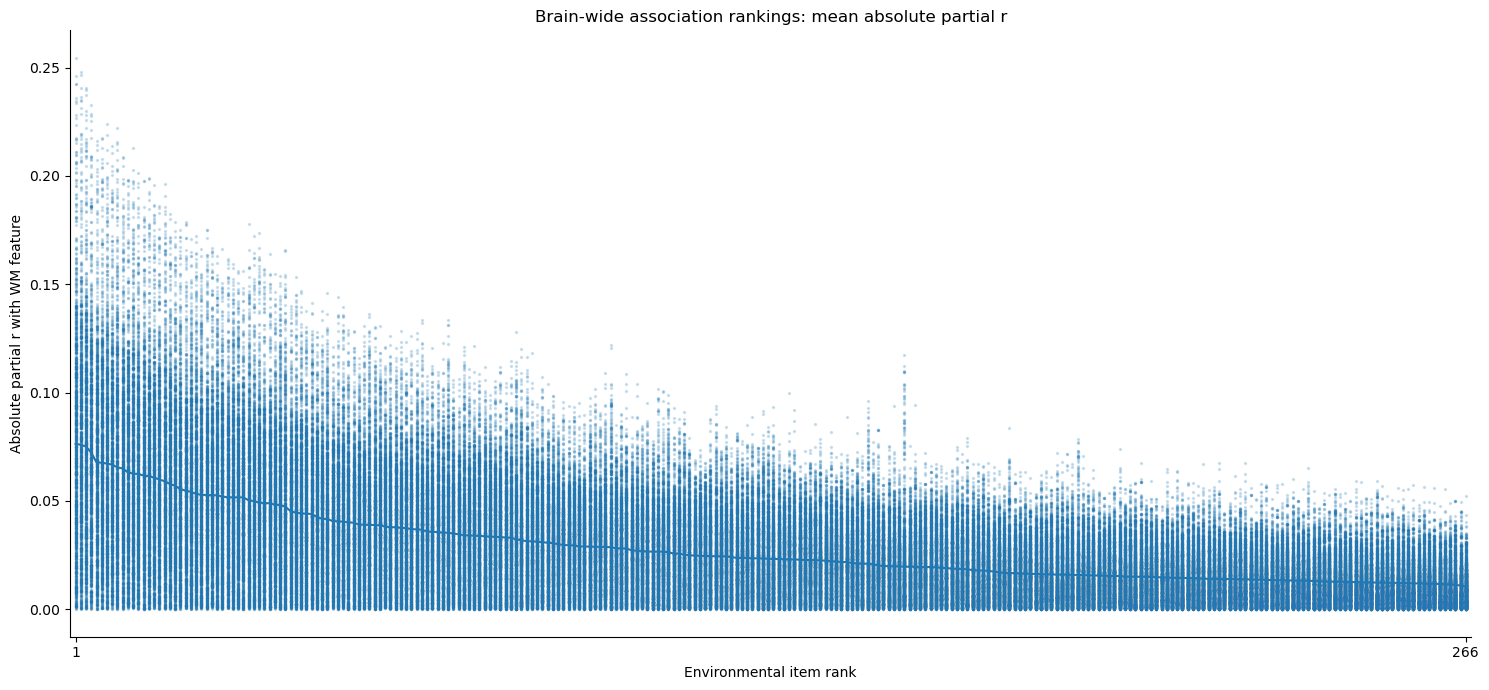

Top 25 by mean |partial r|:


,variable,n,missing_pct_in_imaging_sample,mean_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome
0,parent_ses,4074,0.098087,0.076370,1046,0.989394
1,hshld_inc,4074,0.098087,0.075859,1057,0.991361
2,addr_poverty,3747,8.116724,0.075079,1045,-0.984194
3,reshist_addr1_coi_c5_coi_nat,3747,8.116724,0.072278,1029,0.982516
4,reshist_addr1_coi_se_single,3747,8.116724,0.067743,1006,-0.964849
5,reshist_addr1_coi_se_public,3747,8.116724,0.067624,1000,-0.976114
6,reshist_addr1_coi_se_occ,3747,8.116724,0.067208,969,0.983407
7,reshist_addr1_coi_se_povrate,3747,8.116724,0.066697,1011,-0.971571
8,reshist_addr1_adi_perc,3747,8.116724,0.065411,954,-0.978081
9,reshist_addr1_coi_r_he_nat,3747,8.116724,0.064951,984,0.982420


In [12]:
rank_mean=summary.sort_values("mean_abs_partial_r",ascending=False)["variable"].tolist()
rank_lookup={v:i for i,v in enumerate(rank_mean)}
plot_df=results_long[["variable","partial_r"]].copy()
plot_df["x"]=plot_df["variable"].map(rank_lookup)
plot_df["abs_partial_r"]=plot_df["partial_r"].abs()
mean_line=summary.set_index("variable").loc[rank_mean,"mean_abs_partial_r"].to_numpy()

fig,ax=plt.subplots(figsize=(15,7))
ax.scatter(plot_df["x"],plot_df["abs_partial_r"],s=2,alpha=.18,rasterized=True)
ax.plot(np.arange(len(rank_mean)),mean_line,lw=1.5)
ax.set_xlim(-1,len(rank_mean))
ax.set_xlabel("Environmental item rank")
ax.set_ylabel("Absolute partial r with WM feature")
ax.set_title("Brain-wide association rankings: mean absolute partial r")
ax.set_xticks([0,len(rank_mean)-1] if len(rank_mean)>1 else [0])
ax.set_xticklabels(["1",str(len(rank_mean))] if len(rank_mean)>1 else ["1"])
sns.despine()
plt.tight_layout()
fig.savefig(OUT_DIR/"brainwide_rank_mean_abs_partial_r.png",dpi=400,bbox_inches="tight")
fig.savefig(OUT_DIR/"brainwide_rank_mean_abs_partial_r.svg",bbox_inches="tight")
plt.show()

print("Top 25 by mean |partial r|:")
display(summary.sort_values("mean_abs_partial_r",ascending=False).head(25)[[
    "variable","n","missing_pct_in_imaging_sample","mean_abs_partial_r","n_fdr_sig","map_r_vs_general_exposome"
]])

## 11. Brain-wide ranking by number of FDR-significant WM features

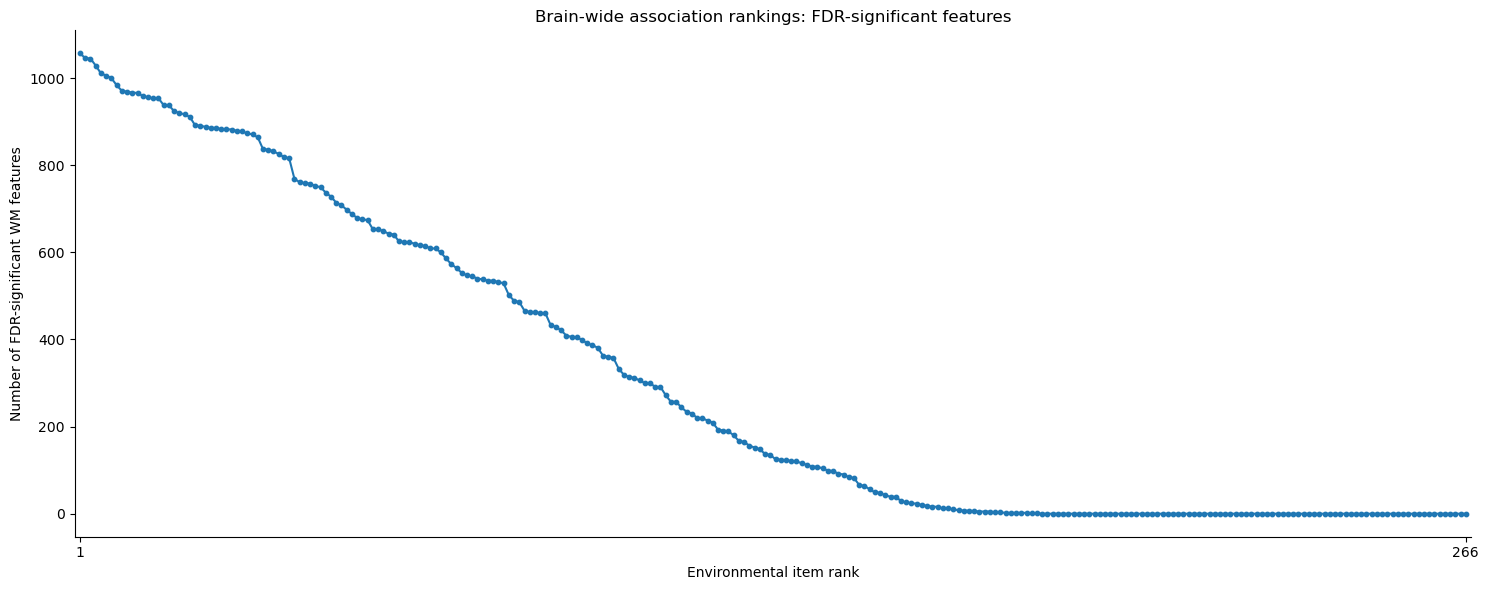

Top 25 by number of FDR-significant features:


,variable,n,missing_pct_in_imaging_sample,n_fdr_sig,mean_abs_partial_r,fdr_overlap_with_general_n,fdr_overlap_pct_of_item,map_r_vs_general_exposome
0,hshld_inc,4074,0.098087,1057,0.075859,1043,98.675497,0.991361
1,parent_ses,4074,0.098087,1046,0.076370,1032,98.661568,0.989394
2,addr_poverty,3747,8.116724,1045,0.075079,1025,98.086124,-0.984194
3,reshist_addr1_coi_c5_coi_nat,3747,8.116724,1029,0.072278,1008,97.959184,0.982516
4,reshist_addr1_coi_se_povrate,3747,8.116724,1011,0.066697,996,98.516320,-0.971571
5,reshist_addr1_coi_se_single,3747,8.116724,1006,0.067743,980,97.415507,-0.964849
6,reshist_addr1_coi_se_public,3747,8.116724,1000,0.067624,982,98.200000,-0.976114
7,reshist_addr1_coi_r_he_nat,3747,8.116724,984,0.064951,973,98.882114,0.982420
8,reshist_addr1_adi_unemp,3747,8.116724,971,0.060761,948,97.631308,-0.967827
9,reshist_addr1_coi_se_occ,3747,8.116724,969,0.067208,962,99.277606,0.983407


In [13]:
rank_fdr=summary.sort_values(["n_fdr_sig","mean_abs_partial_r"],ascending=[False,False]).reset_index(drop=True)

fig,ax=plt.subplots(figsize=(15,6))
x=np.arange(len(rank_fdr))
ax.plot(x,rank_fdr["n_fdr_sig"].to_numpy(),lw=1.5)
ax.scatter(x,rank_fdr["n_fdr_sig"].to_numpy(),s=10)
ax.set_xlim(-1,len(rank_fdr))
ax.set_xlabel("Environmental item rank")
ax.set_ylabel("Number of FDR-significant WM features")
ax.set_title("Brain-wide association rankings: FDR-significant features")
ax.set_xticks([0,len(rank_fdr)-1] if len(rank_fdr)>1 else [0])
ax.set_xticklabels(["1",str(len(rank_fdr))] if len(rank_fdr)>1 else ["1"])
sns.despine()
plt.tight_layout()
fig.savefig(OUT_DIR/"brainwide_rank_n_fdr_significant.png",dpi=400,bbox_inches="tight")
fig.savefig(OUT_DIR/"brainwide_rank_n_fdr_significant.svg",bbox_inches="tight")
plt.show()

print("Top 25 by number of FDR-significant features:")
display(rank_fdr.head(25)[[
    "variable","n","missing_pct_in_imaging_sample","n_fdr_sig","mean_abs_partial_r",
    "fdr_overlap_with_general_n","fdr_overlap_pct_of_item","map_r_vs_general_exposome"
]])

## 12. General Exposome comparison

In [14]:
comparison_cols=[
    "variable","n","missing_pct_in_imaging_sample","mean_abs_partial_r","n_fdr_sig",
    "map_r_vs_general_exposome","fdr_overlap_with_general_n","fdr_overlap_pct_of_item",
    "rank_mean_abs_r","rank_n_fdr"
]
comparison=summary[comparison_cols].sort_values("map_r_vs_general_exposome",ascending=False)
comparison.to_csv(OUT_DIR/"item_vs_general_exposome_comparison.csv",index=False)
display(comparison.head(40))

,variable,n,missing_pct_in_imaging_sample,mean_abs_partial_r,n_fdr_sig,map_r_vs_general_exposome,fdr_overlap_with_general_n,fdr_overlap_pct_of_item,rank_mean_abs_r,rank_n_fdr
1,hshld_inc,4074,0.098087,0.075859,1057,0.991361,1043,98.675497,2,1
0,parent_ses,4074,0.098087,0.076370,1046,0.989394,1032,98.661568,1,2
6,reshist_addr1_coi_se_occ,3747,8.116724,0.067208,969,0.983407,962,99.277606,7,10
3,reshist_addr1_coi_c5_coi_nat,3747,8.116724,0.072278,1029,0.982516,1008,97.959184,4,4
9,reshist_addr1_coi_r_he_nat,3747,8.116724,0.064951,984,0.982420,973,98.882114,10,8
12,reshist_addr1_coi_se_mhe,3747,8.116724,0.062348,956,0.976685,942,98.535565,13,14
17,reshist_addr1_coi_r_ed_nat,3747,8.116724,0.059058,917,0.976002,908,99.018539,18,21
11,prnts_edu,4074,0.098087,0.062592,938,0.969961,926,98.720682,12,17
20,reshist_addr1_coi_he_hlthins,3747,8.116724,0.055460,892,0.968613,883,98.991031,21,23
23,reshist_addr1_coi_c5_he_met,3747,8.116724,0.053167,873,0.967517,861,98.625430,24,33


## 14. Quick output inventory

In [15]:
print("Main outputs:")
for p in sorted(OUT_DIR.iterdir()):
    if p.is_file():
        print(" -",p.name)
print(f"\nItem heatmaps: {len(list(HEATMAP_DIR.glob('*.png')))}")

Main outputs:
 - General_SES_mass_univariate_reference.csv
 - all_item_mass_univariate_results.csv
 - brainwide_rank_mean_abs_partial_r.png
 - brainwide_rank_mean_abs_partial_r.svg
 - brainwide_rank_n_fdr_significant.png
 - brainwide_rank_n_fdr_significant.svg
 - item_99999_replacements.csv
 - item_mass_univariate_summary.csv
 - item_missingness_and_type.csv
 - item_missingness_and_type_after_99999_cleanup.csv
 - item_missingness_in_imaging_sample.csv
 - item_vs_general_exposome_comparison.csv
 - skipped_items.csv

Item heatmaps: 157
